In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# 00 — Data Preprocessing

Loads the raw **Homesite** training CSV and produces a clean, feature-rich tabular representation for the temporal experiment pipeline.

**Input:** raw `train.csv`  
**Output:** `data/processed/X.parquet`, `X_num.parquet`, `X_bin.parquet`, `Y.npy`, `meta.parquet`, `feature_names.json`


In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

WORKSPACE = Path('/content/drive/MyDrive/Home Insurance MLP')
RAW_DIR   = WORKSPACE / 'data' / 'raw'
PROC_DIR  = WORKSPACE / 'data' / 'processed'
FIG_DIR   = PROC_DIR / 'figures'

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

RAW_CSV = RAW_DIR / 'train.csv'

if not RAW_CSV.exists():
    candidates = list(Path('/content/drive/MyDrive').rglob('train.csv')) + list(Path('/content').rglob('train.csv'))
    candidates = [p for p in candidates if 'home' in str(p).lower() or 'insurance' in str(p).lower() or 'homesite' in str(p).lower()] + candidates
    if candidates:
        RAW_CSV = candidates[0]

print(f'RAW_CSV : {RAW_CSV}')
print(f'PROC_DIR: {PROC_DIR}')


RAW_CSV : /content/drive/MyDrive/Home Insurance MLP/data/raw/train.csv
PROC_DIR: /content/drive/MyDrive/Home Insurance MLP/data/processed


## 1. Load raw Homesite training data

Read the CSV once, inspect its shape and data types, and confirm the dataset is available in the expected workspace.


In [3]:
df = pd.read_csv(RAW_CSV)

print(f'Raw shape: {df.shape}')
print(df.dtypes.value_counts())
df.head(3)


Raw shape: (260753, 299)
int64      265
object      28
float64      6
Name: count, dtype: int64


,QuoteNumber,Original_Quote_Date,QuoteConversion_Flag,Field6,Field7,Field8,Field9,Field10,Field11,Field12,...,GeographicField59A,GeographicField59B,GeographicField60A,GeographicField60B,GeographicField61A,GeographicField61B,GeographicField62A,GeographicField62B,GeographicField63,GeographicField64
0,1,2013-08-16,0,B,23,0.9403,0.0006,965,1.0200,N,...,9,9,-1,8,-1,18,-1,10,N,CA
1,2,2014-04-22,0,F,7,1.0006,0.0040,548,1.2433,N,...,10,10,-1,11,-1,17,-1,20,N,NJ
2,4,2014-08-25,0,F,7,1.0006,0.0040,548,1.2433,N,...,15,18,-1,21,-1,11,-1,8,N,NJ


## 2. Parse the timestamp and build a stable row identity

The temporal methodology downstream depends on a chronologically sorted table with a stable row index that can be reused across all notebooks.


In [4]:
required_cols = ['QuoteNumber', 'Original_Quote_Date', 'QuoteConversion_Flag']
missing_required = [c for c in required_cols if c not in df.columns]
assert not missing_required, f'Missing required columns: {missing_required}'

df['Original_Quote_Date'] = pd.to_datetime(df['Original_Quote_Date'], errors='coerce')
assert df['Original_Quote_Date'].notna().all(), 'Unparseable dates found in Original_Quote_Date'

df = df.sort_values(['Original_Quote_Date', 'QuoteNumber']).reset_index(drop=True)
df['row_id'] = np.arange(len(df), dtype=np.int64)

print(f'Date range: {df["Original_Quote_Date"].min()} → {df["Original_Quote_Date"].max()}')
print(f'Positive rate: {df["QuoteConversion_Flag"].mean():.4f}')
print(f'Rows after sort: {len(df):,}')


Date range: 2013-01-01 00:00:00 → 2015-05-18 00:00:00
Positive rate: 0.1875
Rows after sort: 260,753


## 3. Build the metadata table

`meta.parquet` is the chronological spine of the whole pipeline. It stores the parsed quote date, the label, and the stable row identity used by the rolling-window setup.


In [5]:
meta = df[['row_id', 'QuoteNumber', 'Original_Quote_Date', 'QuoteConversion_Flag']].rename(
    columns={
        'Original_Quote_Date': 'quote_date',
        'QuoteConversion_Flag': 'label'
    }
).copy()

meta['year'] = meta['quote_date'].dt.year.astype(np.int16)
meta['month'] = meta['quote_date'].dt.month.astype(np.int8)

print(meta.head(3))
print(meta.dtypes)


   row_id  QuoteNumber quote_date  label  year  month
0       0         3489 2013-01-01      0  2013      1
1       1        24916 2013-01-01      0  2013      1
2       2        25137 2013-01-01      0  2013      1
row_id                  int64
QuoteNumber             int64
quote_date     datetime64[ns]
label                   int64
year                    int16
month                    int8
dtype: object


## 4. Separate raw feature columns

Keep the timestamp, identifier, and target outside `X`. Everything else becomes part of the model input matrix.


In [6]:
drop_from_X = ['row_id', 'QuoteNumber', 'Original_Quote_Date', 'QuoteConversion_Flag']
feature_source = df.drop(columns=drop_from_X).copy()

obj_cols = feature_source.select_dtypes(include='object').columns.tolist()
num_cols_raw = [c for c in feature_source.columns if c not in obj_cols]

print(f'Total candidate features: {feature_source.shape[1]}')
print(f'Numeric/raw integer-float columns: {len(num_cols_raw)}')
print(f'Object columns: {len(obj_cols)}')
print(obj_cols)


Total candidate features: 296
Numeric/raw integer-float columns: 269
Object columns: 27
['Field6', 'Field10', 'Field12', 'CoverageField8', 'CoverageField9', 'SalesField7', 'PersonalField7', 'PersonalField16', 'PersonalField17', 'PersonalField18', 'PersonalField19', 'PropertyField3', 'PropertyField4', 'PropertyField5', 'PropertyField7', 'PropertyField14', 'PropertyField28', 'PropertyField30', 'PropertyField31', 'PropertyField32', 'PropertyField33', 'PropertyField34', 'PropertyField36', 'PropertyField37', 'PropertyField38', 'GeographicField63', 'GeographicField64']


## 5. Create calendar features from the quote date

We add lightweight calendar-derived features from the original quote date while keeping the downstream rolling windows fully leakage-free.


In [7]:
date_feats = pd.DataFrame({
    'quote_year': df['Original_Quote_Date'].dt.year.astype(np.int16),
    'quote_month': df['Original_Quote_Date'].dt.month.astype(np.int8),
    'quote_day': df['Original_Quote_Date'].dt.day.astype(np.int8),
    'quote_dayofweek': df['Original_Quote_Date'].dt.dayofweek.astype(np.int8),
    'quote_dayofyear': df['Original_Quote_Date'].dt.dayofyear.astype(np.int16),
    'quote_weekofyear': df['Original_Quote_Date'].dt.isocalendar().week.astype(np.int16),
    'quote_quarter': df['Original_Quote_Date'].dt.quarter.astype(np.int8),
    'quote_is_month_start': df['Original_Quote_Date'].dt.is_month_start.astype(np.int8),
    'quote_is_month_end': df['Original_Quote_Date'].dt.is_month_end.astype(np.int8),
    'quote_is_quarter_start': df['Original_Quote_Date'].dt.is_quarter_start.astype(np.int8),
    'quote_is_quarter_end': df['Original_Quote_Date'].dt.is_quarter_end.astype(np.int8),
    'quote_is_weekend': (df['Original_Quote_Date'].dt.dayofweek >= 5).astype(np.int8),
})
date_feats.head(3)


,quote_year,quote_month,quote_day,quote_dayofweek,quote_dayofyear,quote_weekofyear,quote_quarter,quote_is_month_start,quote_is_month_end,quote_is_quarter_start,quote_is_quarter_end,quote_is_weekend
0,2013,1,1,1,1,1,1,1,0,1,0,0
1,2013,1,1,1,1,1,1,1,0,1,0,0
2,2013,1,1,1,1,1,1,1,0,1,0,0


## 6. Missingness indicators

Homesite contains meaningful missingness patterns, so we preserve them explicitly with binary indicator features.


In [8]:
missing_rates = feature_source.isna().mean().sort_values(ascending=False)
missing_cols = missing_rates[missing_rates > 0].index.tolist()

missing_indicators = pd.DataFrame(index=feature_source.index)
for c in missing_cols:
    missing_indicators[f'{c}__missing'] = feature_source[c].isna().astype(np.int8)

print(f'Columns with missing values: {len(missing_cols)}')
print(missing_rates[missing_rates > 0].head(15))


Columns with missing values: 9
PropertyField29    0.769636
PersonalField84    0.476344
PropertyField38    0.004679
PersonalField7     0.000433
PropertyField36    0.000433
PropertyField3     0.000311
PropertyField32    0.000268
PropertyField34    0.000268
PropertyField4     0.000242
dtype: float64


## 7. Ordinal-encode categorical columns

ordinal categorical policy, so object columns are converted to deterministic integer codes.


In [9]:
encoded_obj = pd.DataFrame(index=feature_source.index)
categorical_maps = {}

for c in obj_cols:
    s = feature_source[c].astype('string').fillna('__MISSING__')
    cats = sorted(pd.Series(s.unique()).astype(str).tolist())
    mapping = {v: i for i, v in enumerate(cats)}
    encoded_obj[c] = s.map(mapping).astype(np.int32)
    categorical_maps[c] = mapping

encoded_obj.head(3)


,Field6,Field10,Field12,CoverageField8,CoverageField9,SalesField7,PersonalField7,PersonalField16,PersonalField17,PersonalField18,...,PropertyField30,PropertyField31,PropertyField32,PropertyField33,PropertyField34,PropertyField36,PropertyField37,PropertyField38,GeographicField63,GeographicField64
0,1,7,0,0,9,3,0,28,48,15,...,0,3,1,3,0,0,0,0,1,0
1,1,7,0,0,9,2,0,28,48,15,...,0,0,1,3,1,0,0,0,1,0
2,6,1,0,0,6,2,0,28,48,15,...,0,0,0,2,0,0,0,0,1,3


## 8. Final feature matrix assembly

Numeric columns keep their raw values with missing values filled to `-1`, categorical columns are ordinal-coded, missingness indicators are appended, and calendar features are added.


In [10]:
numeric_part = feature_source[num_cols_raw].copy()

for c in numeric_part.columns:
    if pd.api.types.is_float_dtype(numeric_part[c]):
        numeric_part[c] = numeric_part[c].fillna(-1).astype(np.float32)
    else:
        numeric_part[c] = numeric_part[c].fillna(-1).astype(np.int32)

X_base = pd.concat(
    [
        numeric_part.reset_index(drop=True),
        encoded_obj.reset_index(drop=True),
        missing_indicators.reset_index(drop=True),
        date_feats.reset_index(drop=True),
    ],
    axis=1
)

assert X_base.shape[0] == len(df)
assert not X_base.isnull().any().any()

print(f'X_base shape: {X_base.shape}')
X_base.head(3)


X_base shape: (260753, 317)


,Field7,Field8,Field9,Field11,CoverageField1A,CoverageField1B,CoverageField2A,CoverageField2B,CoverageField3A,CoverageField3B,...,quote_day,quote_dayofweek,quote_dayofyear,quote_weekofyear,quote_quarter,quote_is_month_start,quote_is_month_end,quote_is_quarter_start,quote_is_quarter_end,quote_is_weekend
0,6,0.9219,0.0006,1.0000,8,14,8,14,7,12,...,1,1,1,1,1,1,0,1,0,0
1,23,0.9219,0.0006,1.0000,25,25,25,25,25,25,...,1,1,1,1,1,1,0,1,0,0
2,23,0.9559,0.0004,1.2392,21,24,21,24,19,24,...,1,1,1,1,1,1,0,1,0,0


## 9. Split features into numeric and binary views

Later notebooks need a clean separation between non-binary features and binary indicators, because the MLP preprocessing only transforms the numeric block.


In [11]:
binary_cols = [c for c in X_base.columns if X_base[c].nunique(dropna=False) == 2]
numeric_cols = [c for c in X_base.columns if c not in binary_cols]

X_num = X_base[numeric_cols].copy()
X_bin = X_base[binary_cols].copy()

for c in X_num.columns:
    if pd.api.types.is_float_dtype(X_num[c]):
        X_num[c] = X_num[c].astype(np.float32)
    else:
        X_num[c] = X_num[c].astype(np.int32)

for c in X_bin.columns:
    X_bin[c] = X_bin[c].astype(np.int8)

print(f'X_num shape: {X_num.shape}')
print(f'X_bin shape: {X_bin.shape}')
print(f'Binary columns: {len(binary_cols)}')


X_num shape: (260753, 280)
X_bin shape: (260753, 37)
Binary columns: 37


## 10. Build final artifacts

Save the processed matrices and the feature-name registry in the exact format expected by the downstream rolling-window, training, SHAP, and drift notebooks.


In [12]:
X = pd.concat([X_num, X_bin], axis=1)
Y = meta['label'].values.astype(np.int8)

feature_names = list(X.columns)
num_feature_names = list(X_num.columns)
bin_feature_names = list(X_bin.columns)

assert len(X) == len(Y) == len(meta), 'Row count mismatch'
assert not X.isnull().any().any(), 'NaN values found in X'
assert set(feature_names) == set(num_feature_names) | set(bin_feature_names)

print(f'X    : {X.shape}')
print(f'Y    : {Y.shape}  positives={Y.sum():,} ({Y.mean():.3%})')
print(f'meta : {meta.shape}')


X    : (260753, 317)
Y    : (260753,)  positives=48,894 (18.751%)
meta : (260753, 6)


In [13]:
X.to_parquet(PROC_DIR / 'X.parquet', index=False)
X_num.to_parquet(PROC_DIR / 'X_num.parquet', index=False)
X_bin.to_parquet(PROC_DIR / 'X_bin.parquet', index=False)
np.save(PROC_DIR / 'Y.npy', Y)
meta.to_parquet(PROC_DIR / 'meta.parquet', index=False)

with open(PROC_DIR / 'feature_names.json', 'w') as f:
    json.dump(
        {
            'all': feature_names,
            'num': num_feature_names,
            'bin': bin_feature_names,
            'categorical_maps': categorical_maps
        },
        f,
        indent=2
    )

print('Saved files:')
for fname in ['X.parquet', 'X_num.parquet', 'X_bin.parquet', 'Y.npy', 'meta.parquet', 'feature_names.json']:
    p = PROC_DIR / fname
    print(f'  {fname:<20s} {p.stat().st_size / 1e6:8.2f} MB')


Saved files:
  X.parquet               31.20 MB
  X_num.parquet           30.68 MB
  X_bin.parquet            0.52 MB
  Y.npy                    0.26 MB
  meta.parquet             2.93 MB
  feature_names.json       0.02 MB


## 11. Verification

Reload the saved files once to confirm dimensions, data types, and chronological integrity before moving to the rolling-window notebook.


In [14]:
X_check = pd.read_parquet(PROC_DIR / 'X.parquet')
Y_check = np.load(PROC_DIR / 'Y.npy')
meta_check = pd.read_parquet(PROC_DIR / 'meta.parquet')

print(X_check.shape, Y_check.shape, meta_check.shape)
print(meta_check[['quote_date', 'label']].head())
print(meta_check[['quote_date', 'label']].tail())


(260753, 317) (260753,) (260753, 6)
  quote_date  label
0 2013-01-01      0
1 2013-01-01      0
2 2013-01-01      0
3 2013-01-01      0
4 2013-01-01      0
       quote_date  label
260748 2015-05-18      0
260749 2015-05-18      0
260750 2015-05-18      0
260751 2015-05-18      0
260752 2015-05-18      0


## 12. Quick EDA

A light inspection of the temporal distribution and class prevalence provides a sanity check for the upcoming month-based rolling windows.


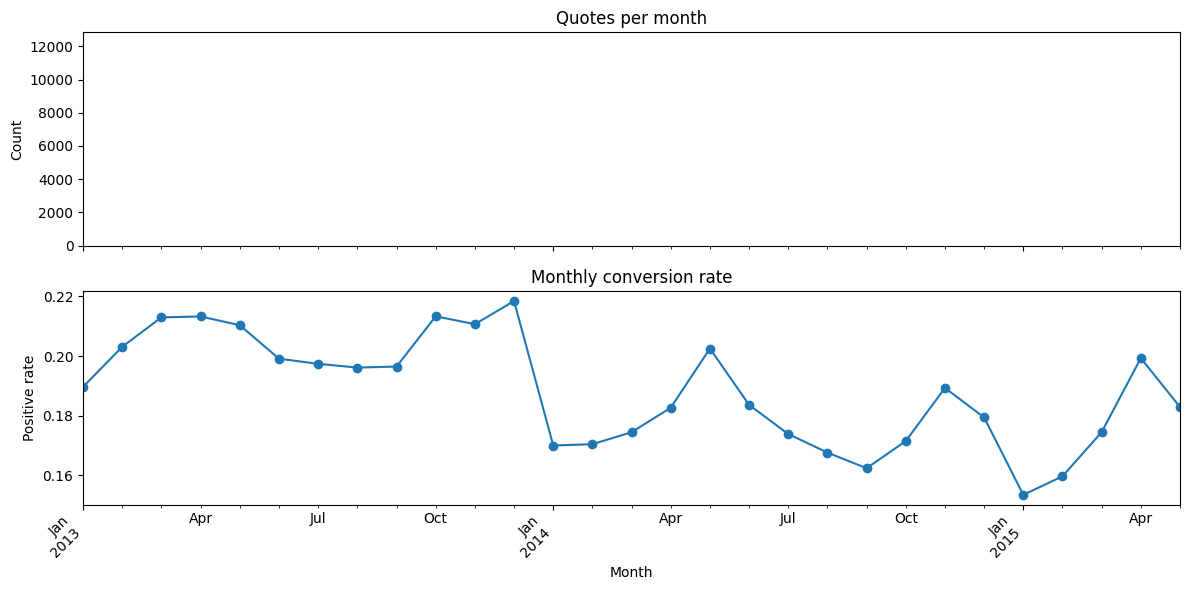

In [15]:
monthly_counts = meta.groupby(meta['quote_date'].dt.to_period('M')).size()
monthly_pos = meta.groupby(meta['quote_date'].dt.to_period('M'))['label'].mean()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

monthly_counts.plot(ax=axes[0], kind='bar', color='steelblue')
axes[0].set_title('Quotes per month')
axes[0].set_ylabel('Count')

monthly_pos.plot(ax=axes[1], kind='line', marker='o')
axes[1].set_title('Monthly conversion rate')
axes[1].set_ylabel('Positive rate')
axes[1].set_xlabel('Month')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'monthly_overview.png', dpi=120)
plt.show()
